## Import libraries

In [1]:
# Setup and Imports
from pathlib import Path
import os, sys

project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))
os.chdir(project_root)

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

from fmu2ml.data.processors import (
    NormalizationHandler,
    DatacenterCoolingDataset,
    SingleChunkSplitDataset,
    create_data_loaders,
    DataValidator,
    ValidationLevel,
    PhysicsValidator
)
from fmu2ml.config import ModelConfig, TrainingConfig
from raps.config import ConfigManager

sns.set_style("whitegrid")
%matplotlib inline

print("✓ Imports complete")

✓ Imports complete


In [4]:
# Configuration
SYSTEM_NAME = 'lassen'
config = ConfigManager(system_name=SYSTEM_NAME).get_config()

# Data paths
DATA_PATH = f'../{SYSTEM_NAME}/data/systematic'
CHUNK_TO_TEST = None
OUTPUT_DIR = f'../results/{SYSTEM_NAME}/data_processing_tests'

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# System parameters
NUM_CDUS = config['NUM_CDUS']
SEQUENCE_LENGTH = 20
BATCH_SIZE = 64
NUM_WORKERS = 48

print(f"System: {SYSTEM_NAME}")
print(f"Number of CDUs: {NUM_CDUS}")
print(f"Data path: {DATA_PATH}")
print(f"Test chunk: {CHUNK_TO_TEST}")
print(f"Sequence length: {SEQUENCE_LENGTH}")
print(f"Output directory: {OUTPUT_DIR}")

System: lassen
Number of CDUs: 44
Data path: ../lassen/data/systematic
Test chunk: None
Sequence length: 20
Output directory: ../results/lassen/data_processing_tests


In [9]:
# Load Raw Data for Inspection
print("="*80)
print("LOADING RAW DATA")
print("="*80)



chunk_path = (Path(DATA_PATH) / f"chunk_{CHUNK_TO_TEST}" ) if CHUNK_TO_TEST else Path(DATA_PATH)
parquet_files = list(chunk_path.glob("*_output_*.parquet"))

if not parquet_files:
    parquet_files = list(chunk_path.glob("*.parquet"))

if not parquet_files:
    raise FileNotFoundError(f"No parquet files found in {chunk_path}")

parquet_file = parquet_files[0]
print(f"Loading: {parquet_file}")

df = pd.read_parquet(parquet_file)

print(f"\nDataset shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
print(f"Samples: {len(df)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

# Display first few rows
display(Markdown("### First 5 rows"))
display(df.head())

LOADING RAW DATA
Loading: ../lassen/data/systematic/systematic_fmu_output_3.8hrs.parquet

Dataset shape: (13650, 1105)
Columns: 1105
Samples: 13650
Memory usage: 120.67 MB


### First 5 rows

,simulator_1_datacenter_1_computeBlock_1_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_2_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_3_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_4_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_5_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_6_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_7_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_8_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_9_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_10_cabinet_1_sources_Q_flow_total,...,simulator[1].datacenter[1].computeBlock[44].cdu[1].summary.p_prim_s,simulator[1].datacenter[1].computeBlock[44].cdu[1].summary.p_prim_s_psig,simulator[1].datacenter[1].computeBlock[44].cdu[1].summary.p_prim_r,simulator[1].datacenter[1].computeBlock[44].cdu[1].summary.p_prim_r_psig,simulator[1].datacenter[1].computeBlock[44].cdu[1].summary.p_sec_s,simulator[1].datacenter[1].computeBlock[44].cdu[1].summary.p_sec_s_psig,simulator[1].datacenter[1].computeBlock[44].cdu[1].summary.p_sec_r,simulator[1].datacenter[1].computeBlock[44].cdu[1].summary.p_sec_r_psig,simulator[1].datacenter[1].computeBlock[44].cabinet[1].summary.htc,pue
0,30948.235061,18804.846008,14695.764023,23152.426072,27165.610557,31339.247466,20311.233504,25863.389014,17328.798528,20386.106718,...,552406.767325,65.616054,364778.283254,38.402843,304800.474678,29.703798,104800.474649,0.696250,50.0,1.182598
1,30948.235061,18815.505673,14786.198451,23269.176003,27128.792246,31339.247466,20329.461144,25834.017589,17516.033597,20386.106718,...,552406.781774,65.616056,364778.311503,38.402847,304800.522859,29.703805,104800.522830,0.696257,50.0,1.182511
2,30948.235061,18826.174237,14814.540806,23382.940926,27124.471707,31339.247466,20322.984839,25825.315160,17709.613874,20386.106718,...,552406.796161,65.616058,364778.339740,38.402851,304800.553872,29.703809,104800.553844,0.696261,50.0,1.182365
3,30948.235061,18836.851678,14790.051712,23493.398360,27069.672035,31339.247466,20397.840543,25878.792517,17908.990632,20386.106718,...,552406.810494,65.616060,364778.367980,38.402855,304800.449431,29.703794,104800.449403,0.696246,50.0,1.182274
4,30948.235061,18847.537978,14742.713021,23600.235201,27072.152157,31339.247466,20399.505711,25819.640072,18113.598717,20386.106718,...,552406.824780,65.616062,364778.396234,38.402860,304800.403770,29.703787,104800.403742,0.696240,50.0,1.182198


In [10]:
# Inspect Column Structure
print("="*80)
print("COLUMN STRUCTURE ANALYSIS")
print("="*80)

# Categorize columns
input_cols = []
output_cols = []
other_cols = []

for col in df.columns:
    if 'sources_Q_flow_total' in col or 'sources_T_Air' in col or 'sources_T_ext' in col:
        input_cols.append(col)
    elif 'cdu[1].summary' in col or 'datacenter[1].summary' in col or 'htc' in col or col == 'pue':
        output_cols.append(col)
    else:
        other_cols.append(col)

print(f"\nInput columns: {len(input_cols)}")
print(f"Output columns: {len(output_cols)}")
print(f"Other columns: {len(other_cols)}")

# Display column samples
display(Markdown("### Sample Input Columns"))
for col in input_cols[:5]:
    print(f"  - {col}")
if len(input_cols) > 5:
    print(f"  ... and {len(input_cols) - 5} more")

display(Markdown("### Sample Output Columns"))
for col in output_cols[:10]:
    print(f"  - {col}")
if len(output_cols) > 10:
    print(f"  ... and {len(output_cols) - 10} more")

COLUMN STRUCTURE ANALYSIS

Input columns: 89
Output columns: 1015
Other columns: 1


### Sample Input Columns

  - simulator_1_datacenter_1_computeBlock_1_cabinet_1_sources_Q_flow_total
  - simulator_1_datacenter_1_computeBlock_2_cabinet_1_sources_Q_flow_total
  - simulator_1_datacenter_1_computeBlock_3_cabinet_1_sources_Q_flow_total
  - simulator_1_datacenter_1_computeBlock_4_cabinet_1_sources_Q_flow_total
  - simulator_1_datacenter_1_computeBlock_5_cabinet_1_sources_Q_flow_total
  ... and 84 more


### Sample Output Columns

  - simulator[1].datacenter[1].summary.m_flow_prim
  - simulator[1].datacenter[1].summary.V_flow_prim_GPM
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.m_flow_prim
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.V_flow_prim_GPM
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.m_flow_sec
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.V_flow_sec_GPM
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.W_flow_CDUP
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.W_flow_CDUP_kW
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s
  - simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s_C
  ... and 1005 more


In [11]:
# Basic Data Statistics
print("="*80)
print("DATA STATISTICS")
print("="*80)

# Input statistics
print("\n### INPUT STATISTICS")
input_df = df[input_cols]

display(Markdown("#### Power Inputs (Q_flow_total)"))
power_cols = [col for col in input_cols if 'Q_flow_total' in col]
power_stats = df[power_cols].describe()
display(power_stats)

display(Markdown("#### Air Temperature Inputs (T_Air - Kelvin)"))
air_temp_cols = [col for col in input_cols if 'T_Air' in col]
air_temp_stats = df[air_temp_cols].describe()
display(air_temp_stats)

display(Markdown("#### External Temperature (T_ext - Kelvin)"))
ext_temp_col = [col for col in input_cols if 'T_ext' in col]
if ext_temp_col:
    ext_temp_stats = df[ext_temp_col].describe()
    display(ext_temp_stats)

# Output statistics
print("\n### OUTPUT STATISTICS")

display(Markdown("#### Primary Flow Rates (GPM)"))
prim_flow_cols = [col for col in output_cols if 'V_flow_prim_GPM' in col][:5]
if prim_flow_cols:
    display(df[prim_flow_cols].describe())

display(Markdown("#### Temperatures (Celsius)"))
temp_output_cols = [col for col in output_cols if 'T_prim_s_C' in col or 'T_prim_r_C' in col][:5]
if temp_output_cols:
    display(df[temp_output_cols].describe())

display(Markdown("#### PUE"))
if 'pue' in df.columns:
    display(df[['pue']].describe())

DATA STATISTICS

### INPUT STATISTICS


#### Power Inputs (Q_flow_total)

,simulator_1_datacenter_1_computeBlock_1_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_2_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_3_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_4_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_5_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_6_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_7_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_8_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_9_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_10_cabinet_1_sources_Q_flow_total,...,simulator_1_datacenter_1_computeBlock_35_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_36_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_37_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_38_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_39_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_40_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_41_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_42_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_43_cabinet_1_sources_Q_flow_total,simulator_1_datacenter_1_computeBlock_44_cabinet_1_sources_Q_flow_total
count,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,...,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000
mean,22562.910085,21591.584629,21293.377476,23843.603785,25558.096290,24170.439317,24104.613111,21837.191662,23777.626448,23172.661139,...,22178.730141,21038.808975,25066.690332,21389.832161,22316.521578,26505.600988,23712.230620,22749.913148,25785.669864,24353.403762
std,4453.472603,5540.197915,4365.118654,2148.485972,4986.194562,6602.459191,5872.227823,2450.596305,6155.885618,4218.559183,...,5154.865705,5403.143991,5070.820722,2712.998900,4812.393786,5989.404161,5272.148584,4531.312690,7039.522375,4375.740268
min,16165.008401,13550.840680,12223.319495,18905.213323,13769.615702,12696.107505,13019.944587,19559.667498,12745.393416,15649.311219,...,12684.136150,11942.044481,15089.170632,17003.939321,13213.086239,13875.675397,14268.680330,12339.578844,13927.440743,16161.651994
25%,18439.350790,15669.094573,18029.843216,24426.266613,23582.031706,19629.814087,19901.834030,20184.625749,17984.745775,20386.106718,...,18332.440982,17038.252280,21265.610350,19601.805583,17925.690350,22536.293100,18916.738178,23211.343849,18894.827870,21058.093854
50%,22206.358635,21597.574076,20599.468863,24426.266613,26620.069180,23621.749013,24707.498522,20342.984231,23974.700660,25122.902216,...,23994.005601,19069.722649,26206.762123,19633.640517,23999.406421,27050.004769,24818.614194,23211.343849,28542.682678,24621.968700
75%,26457.689282,26726.064682,24359.369841,24426.266613,27223.041738,31339.247466,29272.957051,25109.236357,29009.068529,25122.902216,...,25015.453560,23114.840044,26453.840549,23189.537247,26172.747544,31196.910804,28842.658388,23211.343849,31313.295688,26010.359428
max,32085.406358,32268.837181,32565.396532,29031.715010,35854.685433,35067.875458,33483.790496,28570.723139,33956.307099,33412.294338,...,31910.914217,34154.138096,34564.901932,26476.575852,33241.653710,36056.460187,31790.447309,34879.817313,35606.306873,34506.175118


#### Air Temperature Inputs (T_Air - Kelvin)

,simulator_1_datacenter_1_computeBlock_1_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_2_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_3_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_4_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_5_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_6_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_7_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_8_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_9_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_10_cabinet_1_sources_T_Air,...,simulator_1_datacenter_1_computeBlock_35_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_36_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_37_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_38_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_39_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_40_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_41_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_42_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_43_cabinet_1_sources_T_Air,simulator_1_datacenter_1_computeBlock_44_cabinet_1_sources_T_Air
count,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,...,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000
mean,298.391990,298.002377,298.327214,298.668645,298.205028,298.218796,297.956406,298.142453,298.441431,297.996049,...,298.160193,298.576375,298.787887,298.751597,298.443114,299.618001,298.001359,298.181445,298.065954,298.231066
std,1.271078,3.509405,1.497735,0.719857,2.574313,2.601907,0.954898,0.827509,1.484051,1.332056,...,3.155526,2.486418,1.210024,1.567862,1.103970,4.328529,1.818449,1.388996,1.903275,2.935554
min,295.245216,295.910536,295.273292,296.187837,294.657388,294.778568,295.593215,295.988332,296.091828,296.010508,...,296.054306,295.201339,295.026725,295.860340,295.137058,294.026634,294.267279,295.345840,295.254395,294.217835
25%,297.506997,296.271698,297.415018,298.344563,296.326715,296.583059,297.422388,297.547729,297.468373,296.672964,...,296.274147,296.829608,298.301092,297.199277,297.642818,297.485223,296.686137,297.079525,296.529288,296.629673
50%,298.168220,296.886840,298.231791,298.441893,297.751610,297.779701,297.540341,298.139552,298.392029,297.922420,...,296.662454,298.057638,298.462143,298.982275,298.414357,298.730567,298.408762,298.015565,298.086064,297.422833
75%,299.085650,298.142163,298.961642,298.699350,299.334113,298.806079,298.784939,298.737442,298.977393,299.465984,...,299.732154,299.655062,299.844494,299.822995,299.254822,300.272322,299.172386,298.994144,298.950099,299.172520
max,301.294127,313.915605,304.743288,301.026005,306.147007,307.097516,300.457899,300.223386,304.612478,300.473686,...,311.892955,306.342057,302.575417,302.840642,301.016851,313.104837,301.377778,303.697060,303.731939,308.200222


...

,simulator[1].datacenter[1].summary.V_flow_prim_GPM,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.V_flow_prim_GPM,simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.V_flow_prim_GPM,simulator[1].datacenter[1].computeBlock[3].cdu[1].summary.V_flow_prim_GPM,simulator[1].datacenter[1].computeBlock[4].cdu[1].summary.V_flow_prim_GPM
count,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000
mean,388.124400,8.756174,8.756162,8.756146,8.756165
std,4.865600,0.007117,0.007116,0.007110,0.007111
min,386.791770,8.707586,8.707687,8.707707,8.707698
25%,386.826600,8.756964,8.757011,8.757024,8.756995
50%,386.858983,8.757915,8.757895,8.757808,8.757824
75%,386.875794,8.758342,8.758358,8.758389,8.758403
max,420.695306,8.760637,8.760465,8.760503,8.760502


#### Temperatures (Celsius)

,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s_C,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_r_C,simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.T_prim_s_C,simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.T_prim_r_C,simulator[1].datacenter[1].computeBlock[3].cdu[1].summary.T_prim_s_C
count,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000
mean,18.086797,27.790456,18.086775,26.946618,18.086775
std,0.021097,0.435229,0.021110,0.274994,0.021110
min,18.039300,27.144575,18.039300,26.385770,18.039300
25%,18.073110,27.465790,18.073099,26.758061,18.073099
50%,18.083809,27.665119,18.083774,26.933287,18.083774
75%,18.104018,28.022335,18.104018,27.085938,18.104018
max,18.167861,28.955916,18.167799,27.519542,18.167799


#### PUE

,pue
count,13650.000000
mean,1.176916
std,0.005482
min,1.160872
25%,1.173738
50%,1.176405
75%,1.180344
max,1.190928


DATA DISTRIBUTION VISUALIZATIONS


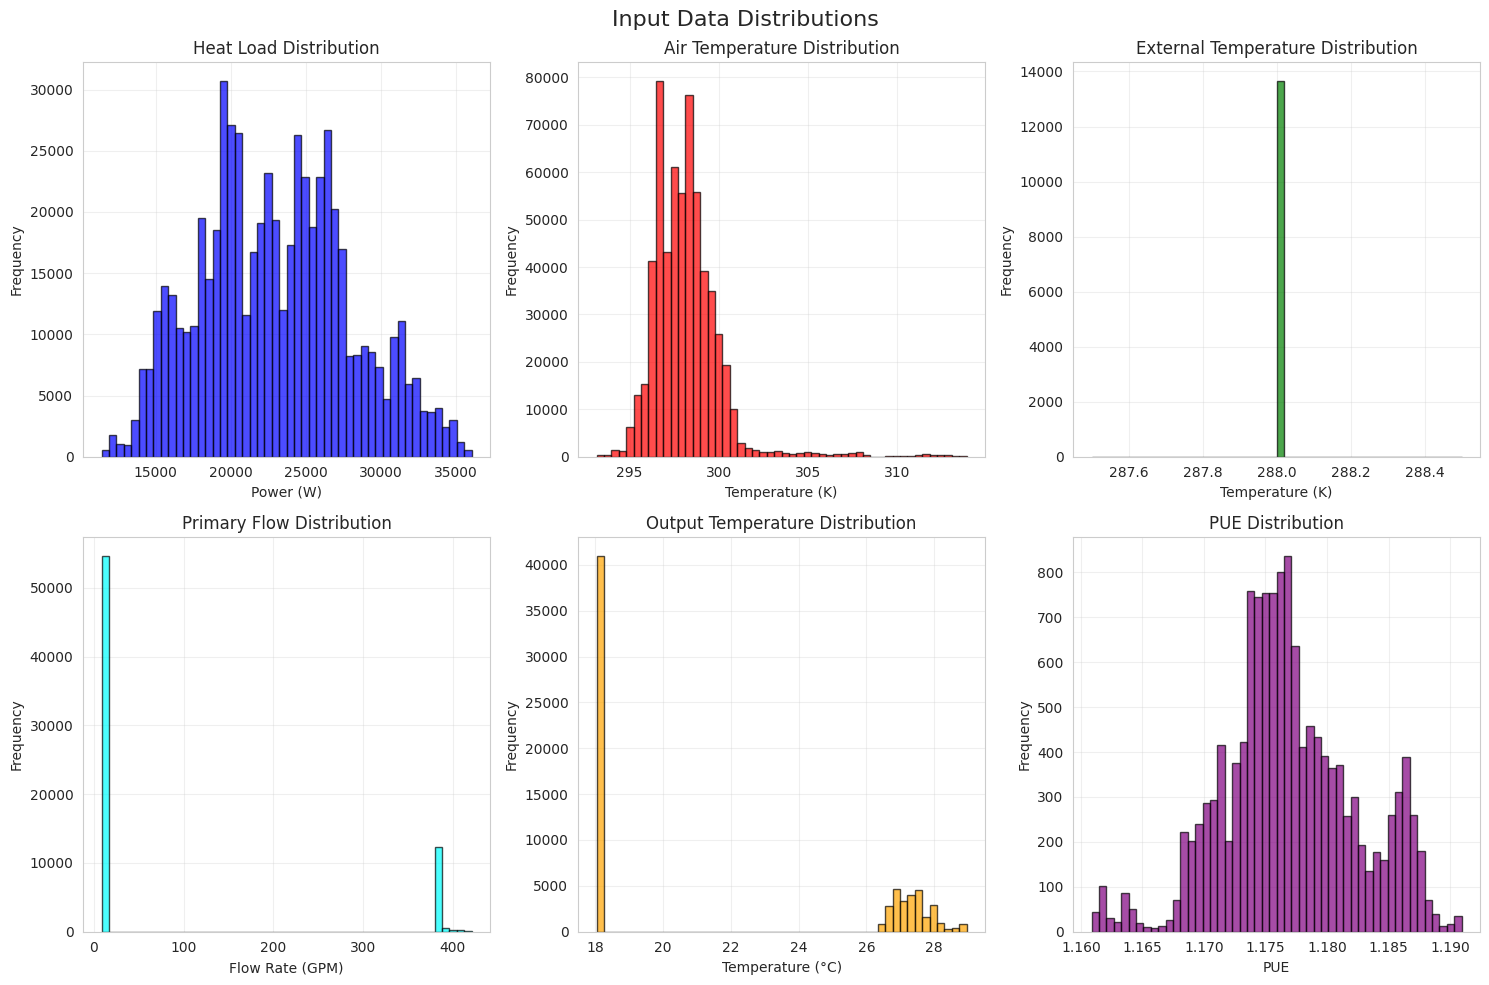

✓ Saved to ../results/lassen/data_processing_tests/data_distributions.png


In [12]:
# Visualize Data Distributions
print("="*80)
print("DATA DISTRIBUTION VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Input Data Distributions', fontsize=16)

# Power distribution
ax = axes[0, 0]
power_data = df[power_cols].values.flatten()
ax.hist(power_data, bins=50, alpha=0.7, color='blue', edgecolor='black')
ax.set_xlabel('Power (W)')
ax.set_ylabel('Frequency')
ax.set_title('Heat Load Distribution')
ax.grid(True, alpha=0.3)

# Air temperature distribution
ax = axes[0, 1]
air_temp_data = df[air_temp_cols].values.flatten()
ax.hist(air_temp_data, bins=50, alpha=0.7, color='red', edgecolor='black')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Frequency')
ax.set_title('Air Temperature Distribution')
ax.grid(True, alpha=0.3)

# External temperature distribution
ax = axes[0, 2]
if ext_temp_col:
    ext_temp_data = df[ext_temp_col[0]].values
    ax.hist(ext_temp_data, bins=50, alpha=0.7, color='green', edgecolor='black')
    ax.set_xlabel('Temperature (K)')
    ax.set_ylabel('Frequency')
    ax.set_title('External Temperature Distribution')
    ax.grid(True, alpha=0.3)

# Flow rate distribution
ax = axes[1, 0]
if prim_flow_cols:
    flow_data = df[prim_flow_cols].values.flatten()
    ax.hist(flow_data, bins=50, alpha=0.7, color='cyan', edgecolor='black')
    ax.set_xlabel('Flow Rate (GPM)')
    ax.set_ylabel('Frequency')
    ax.set_title('Primary Flow Distribution')
    ax.grid(True, alpha=0.3)

# Temperature output distribution
ax = axes[1, 1]
if temp_output_cols:
    temp_out_data = df[temp_output_cols].values.flatten()
    ax.hist(temp_out_data, bins=50, alpha=0.7, color='orange', edgecolor='black')
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Frequency')
    ax.set_title('Output Temperature Distribution')
    ax.grid(True, alpha=0.3)

# PUE distribution
ax = axes[1, 2]
if 'pue' in df.columns:
    ax.hist(df['pue'].values, bins=50, alpha=0.7, color='purple', edgecolor='black')
    ax.set_xlabel('PUE')
    ax.set_ylabel('Frequency')
    ax.set_title('PUE Distribution')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/data_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved to {OUTPUT_DIR}/data_distributions.png")

In [13]:
#  Data Validation - Initialize
print("="*80)
print("DATA VALIDATION")
print("="*80)

validator = DataValidator(config=config, strict=False)
print("✓ Validator initialized")

2026-01-29 21:09:59 - fmu2ml.data.processors.data_validator - INFO - Data validator initialized for datacenter cooling system


DATA VALIDATION
✓ Validator initialized


In [14]:
# Validate Input Data
print("\n" + "="*80)
print("VALIDATING INPUT DATA")
print("="*80)

# Create input DataFrame
input_data = df[input_cols].copy()

# Add time if exists
if 'time' in df.columns:
    input_data['time'] = df['time']

# Validate
input_validation_results = validator.validate(input_data, data_type='input')

# Display summary
input_summary = validator.get_summary_report(input_validation_results)

display(Markdown("### Input Validation Summary"))
print(f"Total checks: {input_summary['total_checks']}")
print(f"Errors: {input_summary['errors']}")
print(f"Warnings: {input_summary['warnings']}")
print(f"Info: {input_summary['infos']}")

# Display errors
if input_summary['error_details']:
    display(Markdown("#### Errors"))
    for error in input_summary['error_details'][:10]:
        print(f"  - {error['message']}")
        if error['column']:
            print(f"    Column: {error['column']}")
        if error['count']:
            print(f"    Count: {error['count']}")

# Display warnings
if input_summary['warning_details']:
    display(Markdown("#### Warnings"))
    for warning in input_summary['warning_details'][:10]:
        print(f"  - {warning['message']}")
        if warning['column']:
            print(f"    Column: {warning['column']}")
        if warning['count']:
            print(f"    Count: {warning['count']}")

2026-01-29 21:10:00 - fmu2ml.data.processors.data_validator - INFO - Validating input data: 13650 samples, 90 columns
2026-01-29 21:10:00 - fmu2ml.data.processors.data_validator - INFO - Validation complete: 28 errors, 9 warnings, 1 info
2026-01-29 21:10:00 - fmu2ml.data.processors.data_validator - ERROR - Validation errors:
2026-01-29 21:10:00 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (35000.00) [simulator_1_datacenter_1_computeBlock_5_cabinet_1_sources_Q_flow_total] (count: 280)



VALIDATING INPUT DATA


2026-01-29 21:10:00 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (35000.00) [simulator_1_datacenter_1_computeBlock_6_cabinet_1_sources_Q_flow_total] (count: 552)
2026-01-29 21:10:00 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (35000.00) [simulator_1_datacenter_1_computeBlock_40_cabinet_1_sources_Q_flow_total] (count: 976)
2026-01-29 21:10:00 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (35000.00) [simulator_1_datacenter_1_computeBlock_43_cabinet_1_sources_Q_flow_total] (count: 1706)
2026-01-29 21:10:00 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (303.15) [simulator_1_datacenter_1_computeBlock_2_cabinet_1_sources_T_Air] (count: 672)
2026-01-29 21:10:00 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (303.15) [simulator_1_datacenter_1_computeBlock_3_cabinet_1_sources_T_Air] (count: 251)
2026-01-29 21:10:00 - fmu2ml.data.processors.data_valid

### Input Validation Summary

Total checks: 38
Errors: 28
Warnings: 9
Info: 1


#### Errors

  - Values above maximum (35000.00)
    Column: simulator_1_datacenter_1_computeBlock_5_cabinet_1_sources_Q_flow_total
    Count: 280
  - Values above maximum (35000.00)
    Column: simulator_1_datacenter_1_computeBlock_6_cabinet_1_sources_Q_flow_total
    Count: 552
  - Values above maximum (35000.00)
    Column: simulator_1_datacenter_1_computeBlock_40_cabinet_1_sources_Q_flow_total
    Count: 976
  - Values above maximum (35000.00)
    Column: simulator_1_datacenter_1_computeBlock_43_cabinet_1_sources_Q_flow_total
    Count: 1706
  - Values above maximum (303.15)
    Column: simulator_1_datacenter_1_computeBlock_2_cabinet_1_sources_T_Air
    Count: 672
  - Values above maximum (303.15)
    Column: simulator_1_datacenter_1_computeBlock_3_cabinet_1_sources_T_Air
    Count: 251
  - Values above maximum (303.15)
    Column: simulator_1_datacenter_1_computeBlock_5_cabinet_1_sources_T_Air
    Count: 1176
  - Values above maximum (303.15)
    Column: simulator_1_datacenter_1_computeBlock_6

#### Warnings

  - Outliers detected (2.77%)
    Column: simulator_1_datacenter_1_computeBlock_11_cabinet_1_sources_Q_flow_total
    Count: 378
  - Outliers detected (4.90%)
    Column: simulator_1_datacenter_1_computeBlock_2_cabinet_1_sources_T_Air
    Count: 669
  - Outliers detected (0.62%)
    Column: simulator_1_datacenter_1_computeBlock_3_cabinet_1_sources_T_Air
    Count: 84
  - Outliers detected (3.63%)
    Column: simulator_1_datacenter_1_computeBlock_6_cabinet_1_sources_T_Air
    Count: 496
  - Outliers detected (1.66%)
    Column: simulator_1_datacenter_1_computeBlock_9_cabinet_1_sources_T_Air
    Count: 226
  - Outliers detected (0.66%)
    Column: simulator_1_datacenter_1_computeBlock_18_cabinet_1_sources_T_Air
    Count: 90
  - Outliers detected (0.76%)
    Column: simulator_1_datacenter_1_computeBlock_27_cabinet_1_sources_T_Air
    Count: 104
  - Outliers detected (3.52%)
    Column: simulator_1_datacenter_1_computeBlock_35_cabinet_1_sources_T_Air
    Count: 480
  - Column has no varia

In [15]:
# Validate Output Data
print("\n" + "="*80)
print("VALIDATING OUTPUT DATA")
print("="*80)

# Create output DataFrame
output_data = df[output_cols].copy()

# Add time if exists
if 'time' in df.columns:
    output_data['time'] = df['time']

# Validate
output_validation_results = validator.validate(output_data, data_type='output')

# Display summary
output_summary = validator.get_summary_report(output_validation_results)

display(Markdown("### Output Validation Summary"))
print(f"Total checks: {output_summary['total_checks']}")
print(f"Errors: {output_summary['errors']}")
print(f"Warnings: {output_summary['warnings']}")
print(f"Info: {output_summary['infos']}")

# Display errors
if output_summary['error_details']:
    display(Markdown("#### Errors"))
    for error in output_summary['error_details'][:10]:
        print(f"  - {error['message']}")
        if error['column']:
            print(f"    Column: {error['column']}")
        if error['count']:
            print(f"    Count: {error['count']}")

# Display warnings
if output_summary['warning_details']:
    display(Markdown("#### Warnings"))
    for warning in output_summary['warning_details'][:10]:
        print(f"  - {warning['message']}")
        if warning['column']:
            print(f"    Column: {warning['column']}")
        if warning['count']:
            print(f"    Count: {warning['count']}")

2026-01-29 21:10:02 - fmu2ml.data.processors.data_validator - INFO - Validating output data: 13650 samples, 1016 columns



VALIDATING OUTPUT DATA


2026-01-29 21:10:05 - fmu2ml.data.processors.data_validator - INFO - Validation complete: 175 errors, 288 warnings, 1 info
2026-01-29 21:10:05 - fmu2ml.data.processors.data_validator - ERROR - Validation errors:
2026-01-29 21:10:05 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (25.00) [simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_sec_s_C] (count: 13650)
2026-01-29 21:10:05 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (40.00) [simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_sec_r_C] (count: 299)
2026-01-29 21:10:05 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (25.00) [simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.T_sec_s_C] (count: 13650)
2026-01-29 21:10:05 - fmu2ml.data.processors.data_validator - ERROR -   - Values above maximum (25.00) [simulator[1].datacenter[1].computeBlock[3].cdu[1].summary.T_sec_s_C] (count: 13650)
2026-01-29 21:10:05 - fmu2ml.data.proc

### Output Validation Summary

Total checks: 464
Errors: 175
Warnings: 288
Info: 1


#### Errors

  - Values above maximum (25.00)
    Column: simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_sec_s_C
    Count: 13650
  - Values above maximum (40.00)
    Column: simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_sec_r_C
    Count: 299
  - Values above maximum (25.00)
    Column: simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.T_sec_s_C
    Count: 13650
  - Values above maximum (25.00)
    Column: simulator[1].datacenter[1].computeBlock[3].cdu[1].summary.T_sec_s_C
    Count: 13650
  - Values above maximum (25.00)
    Column: simulator[1].datacenter[1].computeBlock[4].cdu[1].summary.T_sec_s_C
    Count: 13650
  - Values above maximum (25.00)
    Column: simulator[1].datacenter[1].computeBlock[5].cdu[1].summary.T_sec_s_C
    Count: 13650
  - Values above maximum (40.00)
    Column: simulator[1].datacenter[1].computeBlock[5].cdu[1].summary.T_sec_r_C
    Count: 335
  - Values above maximum (25.00)
    Column: simulator[1].datacenter[1].computeBlock[6].cdu[1]

#### Warnings

  - Outliers detected (4.84%)
    Column: simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.p_prim_s
    Count: 660
  - Outliers detected (4.84%)
    Column: simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.p_prim_s_psig
    Count: 660
  - Outliers detected (2.48%)
    Column: simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.p_prim_r
    Count: 338
  - Outliers detected (2.48%)
    Column: simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.p_prim_r_psig
    Count: 338
  - Outliers detected (0.01%)
    Column: simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.m_flow_sec
    Count: 1
  - Outliers detected (0.01%)
    Column: simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.V_flow_sec_GPM
    Count: 1
  - Outliers detected (4.84%)
    Column: simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.p_prim_s
    Count: 660
  - Outliers detected (4.84%)
    Column: simulator[1].datacenter[1].computeBlock[2].cdu[1].summary.p_prim_s_psig
    

In [16]:
# Normalization - Initialize and Compute Stats
print("="*80)
print("NORMALIZATION")
print("="*80)

# Initialize normalization handler
norm_handler = NormalizationHandler()

# Compute statistics
print("Computing normalization statistics...")
mean_in, std_in, mean_out, std_out = norm_handler.compute_stats(
    df, input_cols, output_cols
)

print(f"✓ Statistics computed")
print(f"  Input features: {len(mean_in)}")
print(f"  Output features: {len(mean_out)}")

# Display sample statistics
display(Markdown("### Input Normalization Statistics"))
print(f"Mean range: [{mean_in.min():.2f}, {mean_in.max():.2f}]")
print(f"Std range: [{std_in.min():.2f}, {std_in.max():.2f}]")

display(Markdown("### Output Normalization Statistics"))
print(f"Mean range: [{mean_out.min():.2f}, {mean_out.max():.2f}]")
print(f"Std range: [{std_out.min():.2f}, {std_out.max():.2f}]")

NORMALIZATION
Computing normalization statistics...
✓ Statistics computed
  Input features: 89
  Output features: 1015


### Input Normalization Statistics

Mean range: [288.00, 26505.60]
Std range: [0.43, 7039.52]


### Output Normalization Statistics

Mean range: [0.55, 552447.44]
Std range: [0.00, 98.01]


In [17]:
# Test Normalization
print("\n" + "="*80)
print("TESTING NORMALIZATION")
print("="*80)

# Sample data
sample_idx = 100
sample_input = df[input_cols].iloc[sample_idx].values
sample_output = df[output_cols].iloc[sample_idx].values

print("Original values:")
print(f"  Input sample: {sample_input[:5]}")
print(f"  Output sample: {sample_output[:5]}")

# Normalize
normalized_input = norm_handler.normalize_input(sample_input)
normalized_output = norm_handler.normalize_output(sample_output)

print("\nNormalized values:")
print(f"  Input sample: {normalized_input[:5]}")
print(f"  Output sample: {normalized_output[:5]}")

# Denormalize
denorm_input = norm_handler.denormalize_input(normalized_input)
denorm_output = norm_handler.denormalize_output(normalized_output)

print("\nDenormalized values:")
print(f"  Input sample: {denorm_input[:5]}")
print(f"  Output sample: {denorm_output[:5]}")

# Verify reconstruction
input_error = np.abs(sample_input - denorm_input).max()
output_error = np.abs(sample_output - denorm_output).max()

print(f"\nReconstruction error:")
print(f"  Input max error: {input_error:.6e}")
print(f"  Output max error: {output_error:.6e}")

if input_error < 1e-6 and output_error < 1e-6:
    print("✓ Normalization/denormalization working correctly")
else:
    print("⚠ Large reconstruction error detected!")


TESTING NORMALIZATION
Original values:
  Input sample: [30948.23506068 19911.4317887  14837.59579939 24416.28176231
 26821.15020491]
  Output sample: [ 24.37628555 386.92516744   0.55182092   8.75906224  20.00000288]

Normalized values:
  Input sample: [ 1.88287333 -0.30326574 -1.47894746  0.26654967  0.25331032]
  Output sample: [-0.24647278 -0.24646954  0.40581713  0.40580225  0.25283626]

Denormalized values:
  Input sample: [30948.23506068 19911.4317887  14837.59579939 24416.28176231
 26821.15020491]
  Output sample: [ 24.37628555 386.92516744   0.55182092   8.75906224  20.00000288]

Reconstruction error:
  Input max error: 0.000000e+00
  Output max error: 0.000000e+00
✓ Normalization/denormalization working correctly


In [18]:
# Save Normalization Statistics
print("\n" + "="*80)
print("SAVING NORMALIZATION STATISTICS")
print("="*80)

stats_path = f"{OUTPUT_DIR}/normalization_stats.npz"
norm_handler.save_stats(stats_path)

print(f"✓ Statistics saved to {stats_path}")
print(f"✓ JSON version saved to {stats_path.replace('.npz', '.json')}")

# Verify loading
norm_handler_loaded = NormalizationHandler(stats_path)
print("✓ Successfully loaded statistics from file")

# Verify loaded stats match
assert np.allclose(norm_handler.mean_in, norm_handler_loaded.mean_in)
assert np.allclose(norm_handler.std_in, norm_handler_loaded.std_in)
print("✓ Loaded statistics match original")


SAVING NORMALIZATION STATISTICS
✓ Statistics saved to ../results/lassen/data_processing_tests/normalization_stats.npz
✓ JSON version saved to ../results/lassen/data_processing_tests/normalization_stats.json
✓ Successfully loaded statistics from file
✓ Loaded statistics match original
